Capstone 2: Business Analysis with Python
Student: Oluwafemi Farinloye  
Program: Year Up United Data Analyst Training Academy — Week 8  

Project Description
This notebook analyzes EmporiUm sales data for two assigned territories:
- Territory 1: Florida — Manager: Lana Ilana — Region: South
- Territory 2: Maryland — Manager: Shruti Reddy — Region: Northeast

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Load StoreSales
store_sales = pd.read_csv('StoreSales.csv')
store_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


In [5]:
# Load StoreDetail
store_detail = pd.read_csv('StoreDetail.csv')
store_detail.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [6]:
# Load Products
products = pd.read_csv('Products.csv')
products.info()


<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [7]:
# Load ProductCategories
product_categories = pd.read_csv('ProductCategories.csv')
product_categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [8]:
# Load customer_list
customer_list = pd.read_csv('customer_list.csv', sep='|')
customer_list.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


In [9]:
## Step 5: Core Marketing Analysis

In [10]:
# Question 1: Territory managers, store IDs and cities
# Filter StoreDetail for Florida and Maryland only
my_territories = store_detail[store_detail['State'].isin(['Florida', 'Maryland'])]

# Display the results
print(my_territories[['State', 'Store ID', 'Store Location', 'Territory Manager', 'Region']])

       State  Store ID       Store Location Territory Manager     Region
26   Florida       719       Cape Canaveral        Lana Ilana      South
27   Florida       720      Fort Lauderdale        Lana Ilana      South
28   Florida       721         Jacksonville        Lana Ilana      South
29   Florida       722             Key West        Lana Ilana      South
30   Florida       723             Lakeland        Lana Ilana      South
31   Florida       724                Miami        Lana Ilana      South
32   Florida       725               Naples        Lana Ilana      South
33   Florida       726              Orlando        Lana Ilana      South
34   Florida       727              Sebring        Lana Ilana      South
35   Florida       728          Tallahassee        Lana Ilana      South
36   Florida       729                Tampa        Lana Ilana      South
43  Maryland       731            Annapolis      Shruti Reddy  Northeast
44  Maryland       732           Back River      Sh

### Question 1 Findings
**Florida** is managed by **Lana Ilana** (South region) and has 11 stores 
(IDs 719–729) in cities including Miami, Orlando, Tampa, and Jacksonville.

**Maryland** is managed by **Shruti Reddy** (Northeast region) and has 9 stores 
(IDs 731–739) in cities including Baltimore, Annapolis, and Germantown.

### Question 2: Monthly Total Revenue by Territory

In [11]:
# Question 2: Monthly total revenue by territory

# Step 1: Merge StoreSales with StoreDetail to get territory/state info
sales_with_state = store_sales.merge(store_detail[['Store ID', 'State']], on='Store ID', how='left')

# Step 2: Filter for Florida and Maryland only
my_sales = sales_with_state[sales_with_state['State'].isin(['Florida', 'Maryland'])]

# Step 3: Convert Transaction Date to a proper date format
my_sales = my_sales.copy()
my_sales['Transaction Date'] = pd.to_datetime(my_sales['Transaction Date'])

# Step 4: Extract Year-Month from the date
my_sales['YearMonth'] = my_sales['Transaction Date'].dt.to_period('M')

# Step 5: Group by State and YearMonth, sum the Sale Amount
monthly_revenue = my_sales.groupby(['State', 'YearMonth'])['Sale Amount'].sum().reset_index()
monthly_revenue.columns = ['State', 'YearMonth', 'Total Revenue']

print(monthly_revenue.to_string())

       State YearMonth  Total Revenue
0    Florida   2022-01       48143.95
1    Florida   2022-02       46257.35
2    Florida   2022-03       53541.25
3    Florida   2022-04       49505.25
4    Florida   2022-05       58326.64
5    Florida   2022-06       48683.24
6    Florida   2022-07       57545.77
7    Florida   2022-08       48656.98
8    Florida   2022-09       42839.10
9    Florida   2022-10       49508.42
10   Florida   2022-11       44519.86
11   Florida   2022-12       50885.58
12   Florida   2023-01       70589.71
13   Florida   2023-02       74547.62
14   Florida   2023-03       71490.80
15   Florida   2023-04       71671.43
16   Florida   2023-05       76942.62
17   Florida   2023-06       75958.75
18   Florida   2023-07       74438.54
19   Florida   2023-08       71626.47
20   Florida   2023-09       86388.39
21   Florida   2023-10       76570.52
22   Florida   2023-11       81150.82
23   Florida   2023-12       85799.00
24   Florida   2024-01       83362.33
25   Florida

### Question 2 Findings
Florida revenue started around $48,000/month in early 2022 and grew 
steadily to over $85,000/month by end of 2023.

Maryland is a significantly larger territory, generating over $300,000 
per month by 2025, showing strong and consistent growth over time.

Both territories show an upward revenue trend across the full data period.

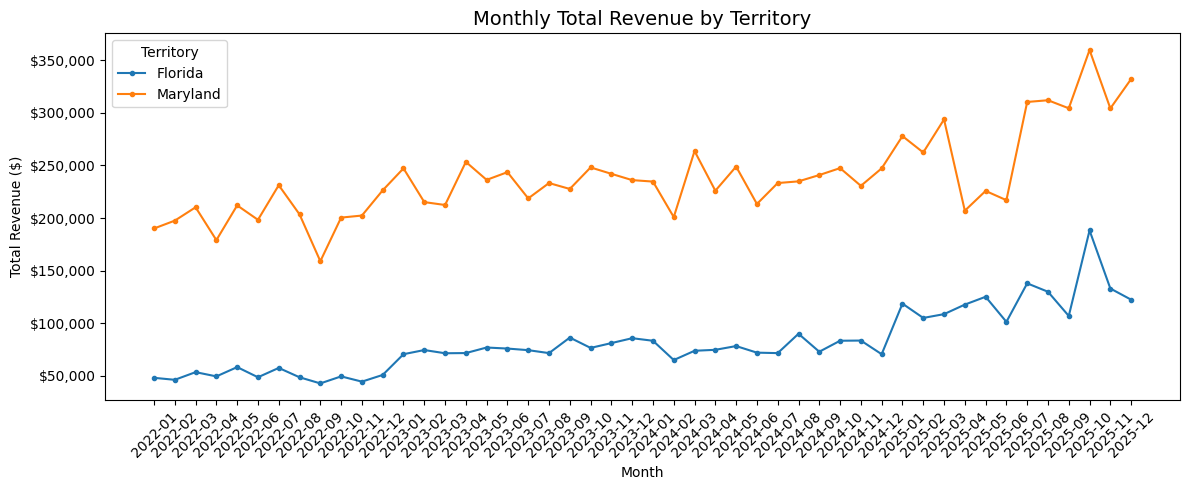

In [12]:
# Chart 1: Monthly Revenue by Territory (Line Chart)
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(12, 5))

for state, group in monthly_revenue.groupby('State'):
    ax.plot(group['YearMonth'].astype(str), group['Total Revenue'], marker='o', label=state, markersize=3)

ax.set_title('Monthly Total Revenue by Territory', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Territory')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Question 3: Store Sales Performance Ranking

In [13]:
# Question 3: Rank stores by total revenue within each territory

store_revenue = my_sales.groupby(['State', 'Store ID'])['Sale Amount'].sum().reset_index()
store_revenue.columns = ['State', 'Store ID', 'Total Revenue']

# Rank stores within each state
store_revenue['Rank'] = store_revenue.groupby('State')['Total Revenue'].rank(ascending=False, method='min').astype(int)

# Sort by state and rank
store_revenue = store_revenue.sort_values(['State', 'Rank'])

print(store_revenue.to_string(index=False))

   State  Store ID  Total Revenue  Rank
 Florida       724      618846.25     1
 Florida       728      541670.66     2
 Florida       722      332620.43     3
 Florida       719      331956.13     4
 Florida       721      331667.08     5
 Florida       727      330848.14     6
 Florida       729      308979.01     7
 Florida       720      302270.07     8
 Florida       726      297891.71     9
 Florida       723      273835.24    10
 Florida       725      259602.83    11
Maryland       736     8708119.00     1
Maryland       734      584675.92     2
Maryland       737      320441.24     3
Maryland       735      319394.58     4
Maryland       739      318511.04     5
Maryland       733      310099.90     6
Maryland       732      303433.61     7
Maryland       738      298074.49     8
Maryland       731      288865.31     9


### Question 3 Findings
In Florida, Store 724 (Miami) is the top performer at $618,846, 
followed by Store 728 (Tallahassee) at $541,670. Store 725 (Naples) 
is the lowest at $259,602.

In Maryland, Store 736 (North Harford) is a massive outlier at 
$8,708,119 — far ahead of all other stores. Store 731 (Annapolis) 
is the lowest at $288,865.

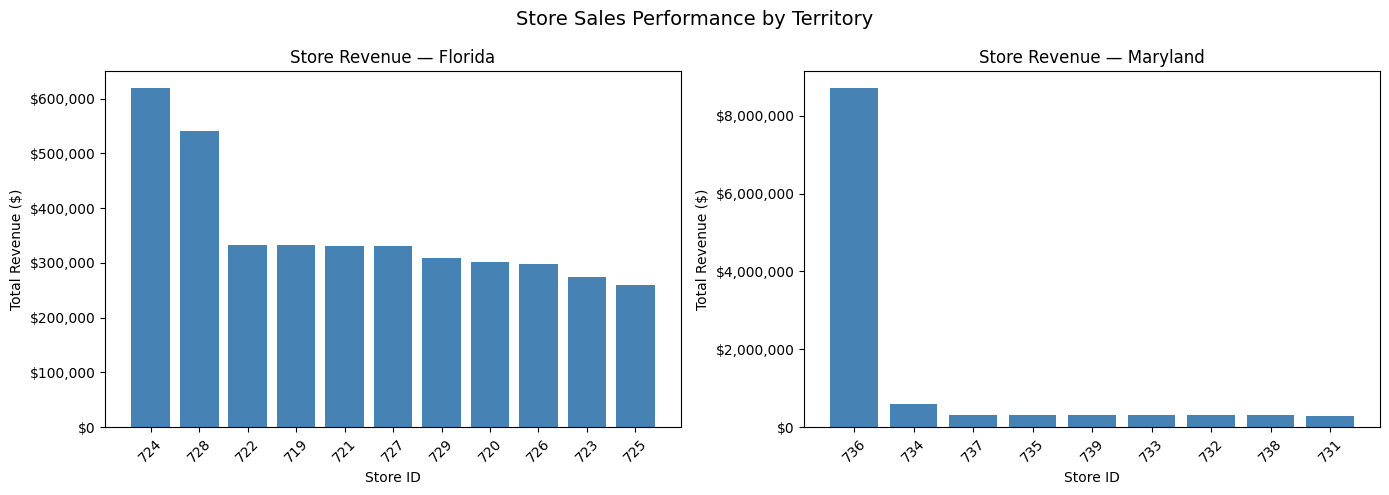

In [14]:
# Chart 2: Store Revenue Ranking by Territory (Bar Chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (state, group) in zip(axes, store_revenue.groupby('State')):
    group_sorted = group.sort_values('Total Revenue', ascending=False)
    ax.bar(group_sorted['Store ID'].astype(str), group_sorted['Total Revenue'], color='steelblue')
    ax.set_title(f'Store Revenue — {state}', fontsize=12)
    ax.set_xlabel('Store ID')
    ax.set_ylabel('Total Revenue ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.setp(ax.get_xticklabels(), rotation=45)

plt.suptitle('Store Sales Performance by Territory', fontsize=14)
plt.tight_layout()
plt.show()

### Question 4: Top Customers by Territory

In [15]:
# Question 4: Top customers by territory
# Merge my_sales with customer_list using RewardsID = cust_id

top_customers = my_sales.merge(customer_list, left_on='RewardsID', right_on='cust_id', how='inner')

# Total spend per customer per state
top_customers = top_customers.groupby(['State', 'cust_id', 'name'])['Sale Amount'].sum().reset_index()
top_customers.columns = ['State', 'Customer ID', 'Name', 'Total Spend']

# Sort by state and total spend
top_customers = top_customers.sort_values(['State', 'Total Spend'], ascending=[True, False])

# Show top 5 per territory
print("--- Top 5 Customers: Florida ---")
print(top_customers[top_customers['State'] == 'Florida'].head(5).to_string(index=False))

print("\n--- Top 5 Customers: Maryland ---")
print(top_customers[top_customers['State'] == 'Maryland'].head(5).to_string(index=False))

--- Top 5 Customers: Florida ---
  State  Customer ID             Name  Total Spend
Florida           47       Stanley H.      4954.99
Florida          259      Todd Chavez      4549.16
Florida          190             Huck      4415.78
Florida          335       John Locke      3631.94
Florida          164 Dr. Ray Flemming      3535.88

--- Top 5 Customers: Maryland ---
   State  Customer ID           Name  Total Spend
Maryland          180     Cole Brown      7602.28
Maryland          355  Donna Hayward      7081.17
Maryland          467 Avon Barksdale      6172.68
Maryland           99     Trent Lane      6076.89
Maryland           75      Magnitude      5916.81


### Question 4 Findings
In Florida, the top customer is Stanley H. with $4,954 in total spend, 
followed by Todd Chavez at $4,549.

In Maryland, the top customer is Cole Brown with $7,602, followed by 
Donna Hayward at $7,081. Maryland's top customers spend significantly 
more than Florida's, reflecting the territory's larger overall revenue.